<a href="https://colab.research.google.com/github/zaimstywn/zaimstywn-Za-im_2025_pengolahan_citra_ti2c/blob/main/Jobsheet4_Za'im.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 04 - Segmentasi Gambar

## Praktikum 01 - Segmentasi Menggunakan Thresholding Global dan Otsu

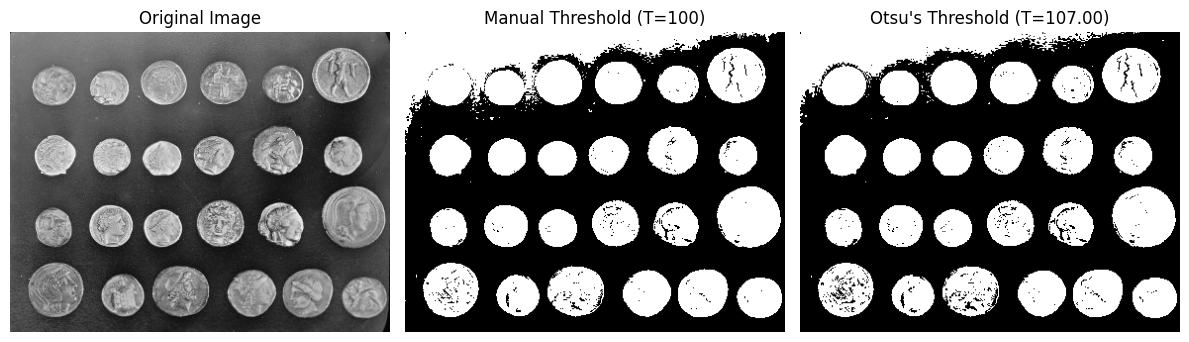

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins() # Citra sudah grayscale

# 2. Thresholding Global (manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

## Praktikum 02 - Segmentasi Menggunakan Region Growing (Contoh Sederhana)

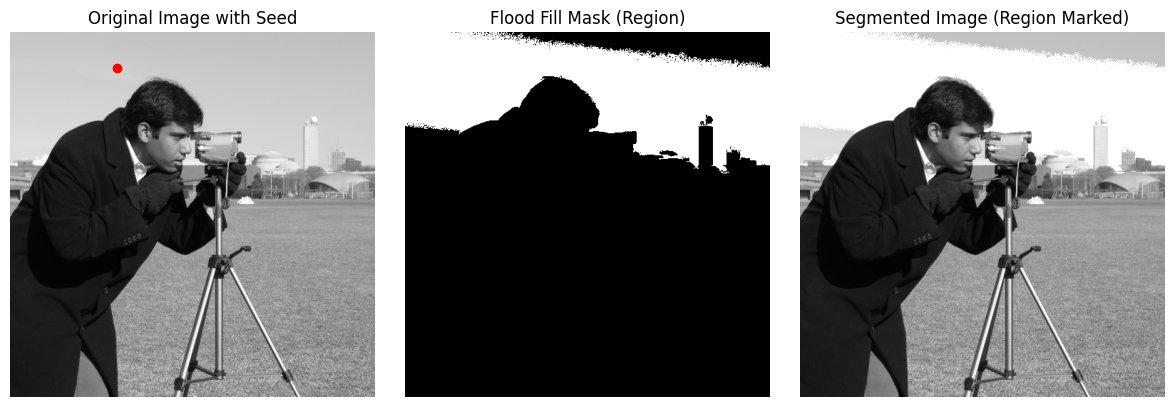

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed'
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()


## Praktikum 03 - Segmentasi Citra Berwarna Menggunakan K-Means Clustering

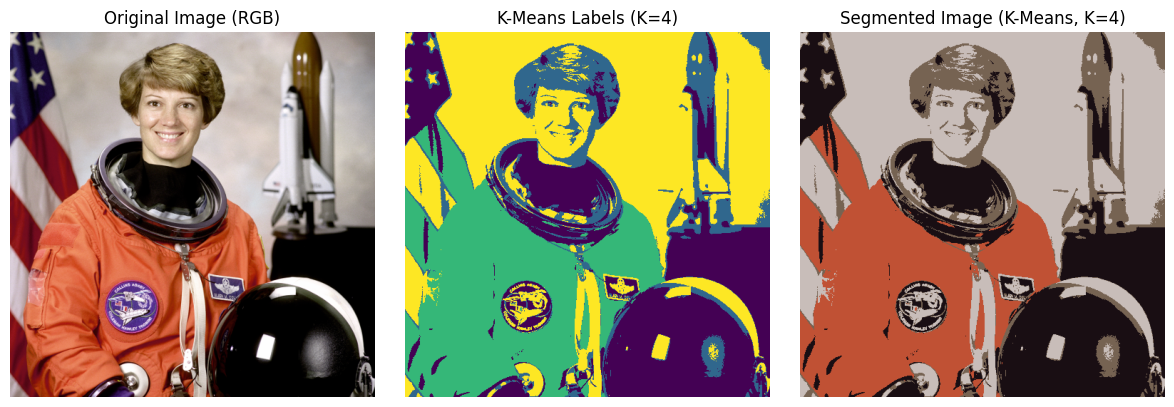

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    cluster_pixels = (pixel_labels == k)
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


## Praktikum 04 - Segmentasi Berbasis Tepi Menggunakan Watershed

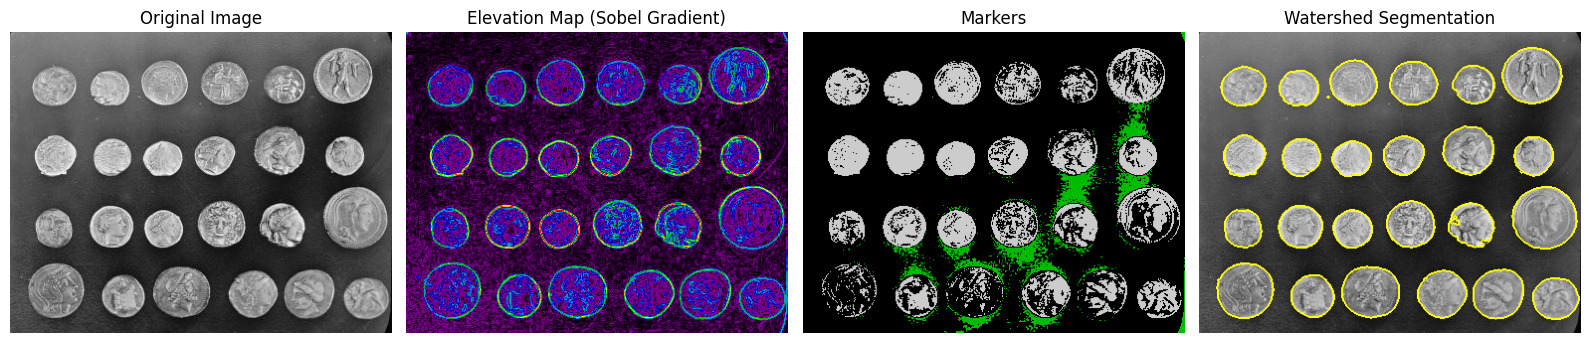

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra
image_coins = data.coins()

# 2. Hitung gradien citra
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()


## Praktikum 05 - Perbandingan Visual Hasil Segmentasi

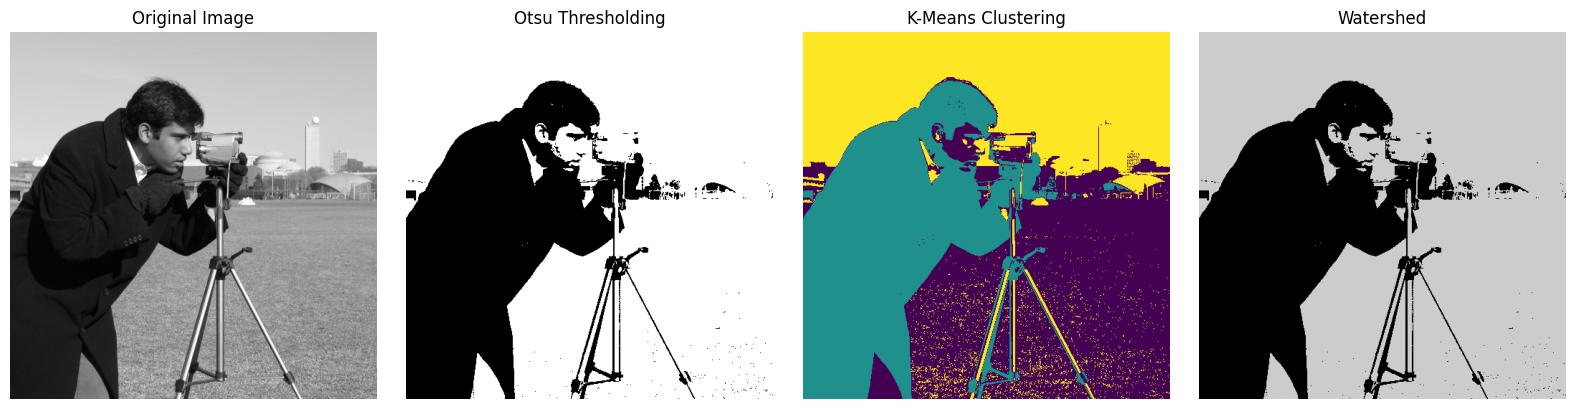

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra
image = data.camera()
image_float = img_as_float(image)

# 2. a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title('K-Means Clustering')
ax[2].axis('off')

ax[3].imshow(segmentation_watershed, cmap='nipy_spectral')
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()


## Penugasan 1 - Eksperimen Thresholding

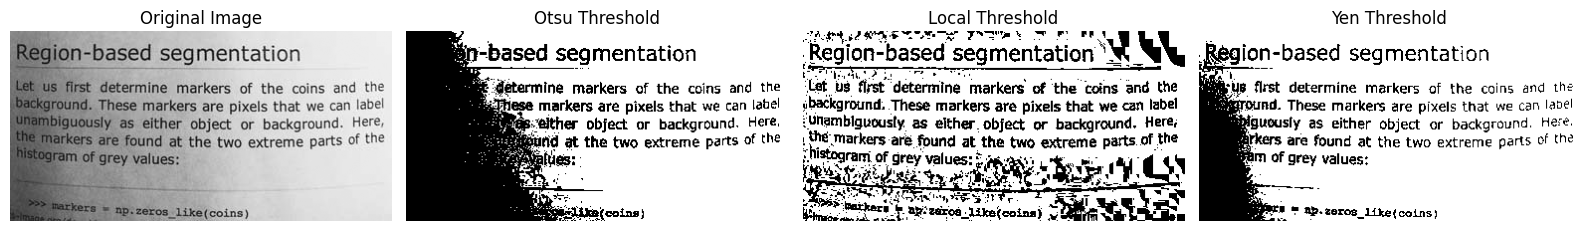

In [1]:
from skimage import data, filters, color
from skimage.filters import threshold_otsu, threshold_local, threshold_yen
import matplotlib.pyplot as plt
import numpy as np

# Load citra
image = data.page()
image_gray = image  # data.page() sudah grayscale

# Thresholding Otsu
thresh_otsu = threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# Thresholding Local
block_size = 35
binary_local = image_gray > threshold_local(image_gray, block_size)

# Thresholding Yen
thresh_yen = threshold_yen(image_gray)
binary_yen = image_gray > thresh_yen

# Visualisasi
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(image_gray, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu Threshold")

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title("Local Threshold")

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title("Yen Threshold")

for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


## Penugasan 2 - Tiga metode segmentasi yang berbeda

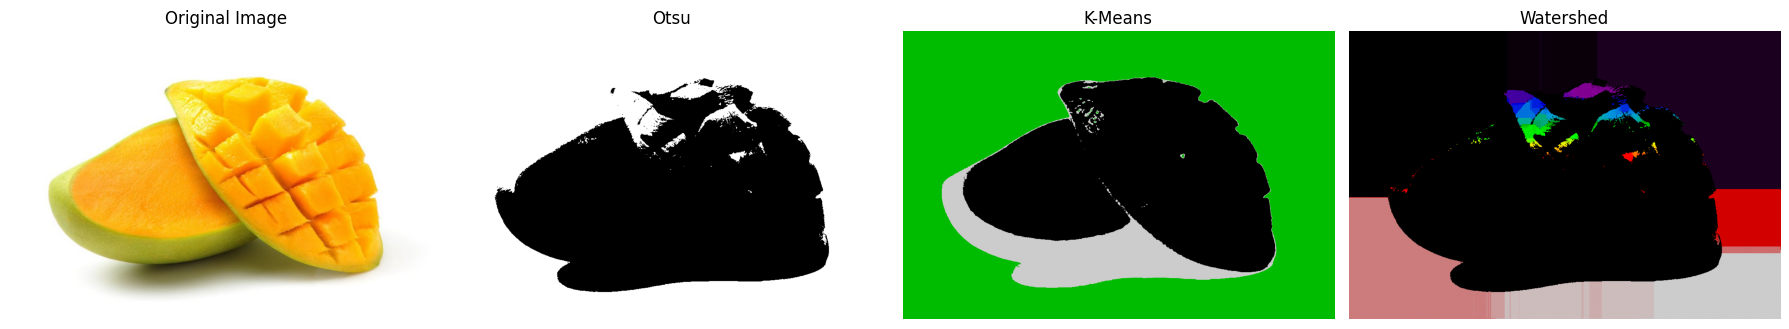

In [3]:
from skimage.io import imread
from skimage.color import rgb2gray, rgb2lab
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import disk
from skimage import morphology
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import cv2

# Load gambar
image = imread('buah.jpg')
gray = rgb2gray(image)

# --- Otsu ---
thresh = threshold_otsu(gray)
binary_otsu = gray > thresh

# --- K-Means ---
image_lab = rgb2lab(image)
n_rows, n_cols, n_channels = image.shape
X = image_lab.reshape((-1, 3))
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
seg_kmeans = kmeans.labels_.reshape((n_rows, n_cols))

# --- Watershed ---
distance = ndi.distance_transform_edt(binary_otsu)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=binary_otsu)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels_ws = watershed(-distance, markers, mask=binary_otsu)

# Visualisasi
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu")
ax[2].imshow(seg_kmeans, cmap='nipy_spectral')
ax[2].set_title("K-Means")
ax[3].imshow(labels_ws, cmap='nipy_spectral')
ax[3].set_title("Watershed")

for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()
